In [1]:
from pathlib import Path
import os
os.chdir('/home/ubuntu/upload')


In [2]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

CATEGORIES = ["KEEP", "ASSOCIATION", "DIFF"]

## Parsing and scoring functions

> **Metric-alignment fix.** The reference scorer converts the literal `Not Applicable` marker to an empty code set before parsing. The upgraded notebook now applies the same normalization to `solution` and every annotator file, and `parse_set` no longer treats `Not Applicable` as a real code.


In [3]:
def parse_set(s):
    """Parse one semicolon-separated code field into a set."""
    if pd.isna(s) or s == "":
        return set()
    return {code.strip() for code in str(s).split("; ") if code.strip()}


def f1_average(true, pred, empty_both="one"):
    """Canonical case-level F1 formula used by section 12.

    empty_both="one" is the standard Results convention. The values "zero"
    and "exclude" are retained for the sensitivity experiment in section 11.
    """
    true_set, pred_set = parse_set(true), parse_set(pred)
    tp = len(true_set & pred_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    if tp == 0 and fp == 0 and fn == 0:
        if empty_both == "one":
            return 1.0
        if empty_both == "zero":
            return 0.0
        if empty_both == "exclude":
            return np.nan
        raise ValueError("empty_both must be 'one', 'zero', or 'exclude'")

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * precision * recall / (precision + recall) if precision + recall else 0.0


def f1_score(true, pred):
    """Standard F1 wrapper using the section 12 convention."""
    return f1_average(true, pred, empty_both="one")


In [4]:
def corpus_kappa(series_a, series_b, vocab=None):
    """Corpus-level Cohen's kappa for multi-label set annotations."""
    sets_a = [parse_set(v) for v in series_a]
    sets_b = [parse_set(v) for v in series_b]
    if vocab is None:
        vocab = set().union(*sets_a, *sets_b) if sets_a else set()
    if not vocab:
        return 1.0
    tp = fp = fn = tn = 0
    for sa, sb in zip(sets_a, sets_b):
        for item in vocab:
            ia, ib = item in sa, item in sb
            if ia and ib:
                tp += 1
            elif ia:
                fp += 1
            elif ib:
                fn += 1
            else:
                tn += 1
    N = tp + fp + fn + tn
    Po = (tp + tn) / N
    p_a_present, p_a_absent = (tp + fp) / N, (fn + tn) / N
    p_b_present, p_b_absent = (tp + fn) / N, (fp + tn) / N
    Pe = p_a_present * p_b_present + p_a_absent * p_b_absent
    if 1 - Pe == 0:
        return 1.0 if Po == 1.0 else 0.0
    return (Po - Pe) / (1 - Pe)

## Generic evaluation function

Replaces the four copy-pasted Overall/Endocrinology/Cardiology/Other blocks in the original notebook, and always compares against `solution` (fixing bug #2).

In [5]:
def mean_f1(df, solution_df, category):
    col_a = df[category].reset_index(drop=True)
    col_b = solution_df[category].reset_index(drop=True)
    return float(np.mean([f1_score(a, b) for a, b in zip(col_a, col_b)]))


def evaluate_against_solution(df, solution_df, categories=CATEGORIES, idx=None):
    """Evaluate one annotator's dataframe against the ground-truth solution.
    idx: optional list of row positions to restrict to (e.g. a specialty subset)."""
    if idx is not None:
        df = df.loc[idx].reset_index(drop=True)
        solution_df = solution_df.loc[idx].reset_index(drop=True)
    row = {}
    for cat in categories:
        row[f"F1_{cat}"] = mean_f1(df, solution_df, cat)
        row[f"Kappa_{cat}"] = corpus_kappa(df[cat], solution_df[cat])
    row["Average_F1"] = float(np.mean([row[f"F1_{c}"] for c in categories]))
    row["Average_Kappa"] = float(np.mean([row[f"Kappa_{c}"] for c in categories]))
    return row

## Load data

In [6]:
solution = pd.read_csv("solution.csv")
annotators = {
    "alan": pd.read_csv("AlanTAndrea.csv"),
    "mdraihan": pd.read_csv("MdRaihan.csv"),
    "monash": pd.read_csv("MonashAIM.csv"),
    "ngoc": pd.read_csv("NgọcHưngNguyễn.csv"),
    "ntua": pd.read_csv("NTUA.csv"),
    "yingfali": pd.read_csv("Yingfali.csv"),
}

# The reference scorer treats both missing values and the literal marker
# "Not Applicable" as an empty code set before computing F1.
for _df in [solution, *annotators.values()]:
    for _category in CATEGORIES:
        _df[_category] = (
            _df[_category]
            .replace(["Not Applicable", "nan", "None", "NaN"], "")
            .fillna("")
            .astype(str)
        )


## Specialty index definitions

Carried over unchanged from the original notebook. The assertion below at least confirms they still form a complete, non-overlapping partition of `solution.csv` — but the indices themselves couldn't be verified against your source data (not included with the notebook), so double check they still match your current row ordering before trusting the specialty breakdown.

In [7]:
cardio = [2, 3, 7, 8, 18, 22]
endo = [5, 9, 12, 15, 17, 19, 20, 21]
other = [0, 1, 4, 6, 10, 11, 13, 14, 16]
assert sorted(cardio + endo + other) == list(range(len(solution))), \
    "Specialty index lists no longer partition all rows of solution.csv - check for a schema change."

## Evaluate every annotator against the ground truth (all specialties, all categories)

In [8]:
specialties = {"Overall": None, "Endocrinology": endo, "Cardiology": cardio, "Other": other}

all_results = []
for spec_name, idx in specialties.items():
    for name, df in annotators.items():
        row = evaluate_against_solution(df, solution, idx=idx)
        row["Specialty"] = spec_name
        row["Annotator"] = name
        all_results.append(row)

results_df = pd.DataFrame(all_results)[
    ["Specialty", "Annotator", "F1_KEEP", "Kappa_KEEP", "F1_ASSOCIATION", "Kappa_ASSOCIATION",
     "F1_DIFF", "Kappa_DIFF", "Average_F1", "Average_Kappa"]
]
results_df.round(3)

,Specialty,Annotator,F1_KEEP,Kappa_KEEP,F1_ASSOCIATION,Kappa_ASSOCIATION,F1_DIFF,Kappa_DIFF,Average_F1,Average_Kappa
0,Overall,alan,0.625,0.678,0.130,-0.004,0.435,0.000,0.397,0.225
1,Overall,mdraihan,0.539,0.467,0.130,0.000,0.435,0.000,0.368,0.156
2,Overall,monash,0.481,0.450,0.130,0.000,0.435,0.000,0.349,0.150
3,Overall,ngoc,0.616,0.691,0.132,-0.002,0.460,0.137,0.403,0.275
4,Overall,ntua,0.545,0.568,0.134,-0.008,0.328,0.120,0.335,0.227
5,Overall,yingfali,0.632,0.656,0.130,0.000,0.472,0.098,0.411,0.251
6,Endocrinology,alan,0.812,0.902,0.000,0.000,0.625,0.000,0.479,0.301
7,Endocrinology,mdraihan,0.691,0.646,0.000,0.000,0.625,0.000,0.439,0.215
8,Endocrinology,monash,0.561,0.411,0.000,0.000,0.625,0.000,0.395,0.137
9,Endocrinology,ngoc,0.680,0.879,0.000,0.000,0.625,0.000,0.435,0.293


In [9]:
# The user-facing F1 comparison is the Private-case table below.


## Pairwise inter-annotator agreement (diagnostic only — **not** vs. solution)

This is what the original notebook's kappa cells actually computed, despite being labeled and displayed as if they were agreement-with-truth. Kept here because inter-annotator agreement is a legitimate and useful diagnostic (it flags annotators who disagree with everyone, or category definitions that are ambiguous) — it's just not the same thing as correctness, so it's shown separately.

In [10]:
names = list(annotators.keys())
iaa_kappa = pd.DataFrame(index=names, columns=names, dtype=float)
for a, b in combinations(names, 2):
    k = corpus_kappa(annotators[a]["KEEP"], annotators[b]["KEEP"])
    iaa_kappa.loc[a, b] = k
    iaa_kappa.loc[b, a] = k
for a in names:
    iaa_kappa.loc[a, a] = 1.0

iaa_kappa.round(3)

,alan,mdraihan,monash,ngoc,ntua,yingfali
alan,1.000,0.556,0.508,0.858,0.733,0.688
mdraihan,0.556,1.000,0.439,0.573,0.713,0.708
monash,0.508,0.439,1.000,0.520,0.402,0.457
ngoc,0.858,0.573,0.520,1.000,0.697,0.754
ntua,0.733,0.713,0.402,0.697,1.000,0.838
yingfali,0.688,0.708,0.457,0.754,0.838,1.000


## Ensemble consensus: union vs. majority vote

The original notebook only ever merged annotators by **union** (an item is kept if *any* annotator flagged it) and only searched combinations for the `KEEP` column. Union merging monotonically increases recall but also accumulates every annotator's false positives, so it doesn't necessarily improve as you add more raters. **Majority vote** (an item is kept only if more than half the annotators agree) is added below as a second strategy, and the search now scores combinations on the average F1 across all three columns (`KEEP`, `ASSOCIATION`, `DIFF`), not just `KEEP`.

In [11]:
def merge_union(dfs, category):
    """An item is kept if ANY annotator flagged it."""
    n = len(dfs[0])
    out = []
    for i in range(n):
        items = set()
        for df in dfs:
            items |= parse_set(df[category].iloc[i])
        out.append("; ".join(sorted(items)) if items else "")
    return pd.Series(out, name=category)


def merge_majority(dfs, category, min_votes=None):
    """An item is kept only if a majority of annotators flagged it."""
    n = len(dfs[0])
    k = len(dfs)
    if min_votes is None:
        min_votes = k // 2 + 1
    out = []
    for i in range(n):
        counts = {}
        for df in dfs:
            for item in parse_set(df[category].iloc[i]):
                counts[item] = counts.get(item, 0) + 1
        items = {it for it, c in counts.items() if c >= min_votes}
        out.append("; ".join(sorted(items)) if items else "")
    return pd.Series(out, name=category)

In [12]:
dfs = list(annotators.values())
ens_results = []
for r in range(1, len(dfs) + 1):
    for combo_idx in combinations(range(len(dfs)), r):
        combo_dfs = [dfs[i] for i in combo_idx]
        combo_names = ", ".join(names[i] for i in combo_idx)
        for strategy, merge_fn in [("union", merge_union), ("majority", merge_majority)]:
            merged = pd.DataFrame({cat: merge_fn(combo_dfs, cat) for cat in CATEGORIES})
            f1s = [mean_f1(merged, solution, cat) for cat in CATEGORIES]
            ens_results.append({
                "dataframes": combo_names,
                "strategy": strategy,
                "avg_f1": float(np.mean(f1s)),
                "f1_keep": f1s[0],
                "f1_association": f1s[1],
                "f1_diff": f1s[2],
            })

ens_df = pd.DataFrame(ens_results).sort_values("avg_f1", ascending=False).reset_index(drop=True)
ens_df.head(10).round(3)

,dataframes,strategy,avg_f1,f1_keep,f1_association,f1_diff
0,"alan, ngoc, yingfali",union,0.438,0.685,0.132,0.497
1,"alan, monash, ngoc, yingfali",union,0.430,0.662,0.132,0.497
2,"mdraihan, ngoc, yingfali",union,0.429,0.657,0.132,0.497
3,"alan, yingfali",union,0.427,0.678,0.130,0.472
4,"alan, mdraihan, ngoc, yingfali",union,0.426,0.651,0.132,0.497
5,"ngoc, yingfali",union,0.426,0.650,0.132,0.497
6,"alan, monash, yingfali",union,0.421,0.662,0.130,0.472
7,"alan, ngoc",union,0.421,0.673,0.132,0.460
8,"monash, ngoc, yingfali",union,0.421,0.635,0.132,0.497
9,"mdraihan, yingfali",union,0.420,0.659,0.130,0.472


# Overview

In [13]:
import numpy as np
import pandas as pd

columns = ["KEEP", "ASSOCIATION", "DIFF"]

def get_stats(df, subset=None):
    if subset is not None:
        df = df.loc[subset]

    df = df.fillna("")
    stats = {}

    for col in columns:
        codes = (
            df[col].str.count(";") + 1
            - df[col].str.count("Not Applicable")
            - df[col].str.count("nan")
        )

        stats[col] = {
            "mean": np.mean(codes),
            "sd": np.std(codes),  # same SD as your original code
            "n": len(codes),
        }

    return stats


subsets = {
    "Overall": None,
    "Cardiology": cardio,
    "Endocrinology": endo,
    "Other": other,
}

rows = {}

for name, df in [*annotators.items(), ("Solution", solution)]:
    for subset_name, subset in subsets.items():
        stats = get_stats(df, subset)

        for col in columns:
            mean = stats[col]["mean"]
            sd = stats[col]["sd"]
            n = stats[col]["n"]

            rows[(subset_name, col, name)] = (
                f"{mean:.2f} ± {sd:.2f} (N={n})"
            )

results = pd.Series(rows).unstack(level=2)

results.index.names = ["Specialty", "Category"]
results.columns.name = None

results

Solution                   alan  \
Specialty     Category                                                    
Cardiology    ASSOCIATION   100.00 ± 70.19 (N=6)      1.00 ± 0.00 (N=6)   
              DIFF         144.50 ± 202.10 (N=6)      1.00 ± 0.00 (N=6)   
              KEEP           62.00 ± 33.38 (N=6)    31.50 ± 17.17 (N=6)   
Endocrinology ASSOCIATION    46.88 ± 31.61 (N=8)      1.00 ± 0.00 (N=8)   
              DIFF           31.50 ± 66.26 (N=8)      1.00 ± 0.00 (N=8)   
              KEEP         101.00 ± 202.33 (N=8)   84.62 ± 186.20 (N=8)   
Other         ASSOCIATION    39.44 ± 47.29 (N=9)     7.00 ± 16.97 (N=9)   
              DIFF           42.89 ± 62.00 (N=9)      1.00 ± 0.00 (N=9)   
              KEEP           94.33 ± 90.70 (N=9)    46.44 ± 58.62 (N=9)   
Overall       ASSOCIATION   57.83 ± 56.09 (N=23)    3.35 ± 11.01 (N=23)   
              DIFF         65.43 ± 126.16 (N=23)     1.00 ± 0.00 (N=23)   
              KEEP         88.22 ± 134.16 (N=23)  55.83 ± 118.14 (N=23)   

                                        mdraihan                monash  \
Specialty     Category                                                   
Cardiology    ASSOCIATION      1.00 ± 0.00 (N=6)     1.00 ± 0.00 (N=6)   
              DIFF             1.00 ± 0.00 (N=6)     1.00 ± 0.00 (N=6)   
              KEEP           22.67 ± 15.39 (N=6)   17.33 ± 10.78 (N=6)   
Endocrinology ASSOCIATION      1.00 ± 0.00 (N=8)     1.00 ± 0.00 (N=8)   
              DIFF             1.00 ± 0.00 (N=8)     1.00 ± 0.00 (N=8)   
              KEEP          60.50 ± 107.84 (N=8)   32.50 ± 53.48 (N=8)   
Other         ASSOCIATION      1.00 ± 0.00 (N=9)     1.00 ± 0.00 (N=9)   
              DIFF             1.00 ± 0.00 (N=9)     1.00 ± 0.00 (N=9)   
              KEEP         100.22 ± 169.35 (N=9)   36.89 ± 47.17 (N=9)   
Overall       ASSOCIATION     1.00 ± 0.00 (N=23)    1.00 ± 0.00 (N=23)   
              DIFF            1.00 ± 0.00 (N=23)    1.00 ± 0.00 (N=23)   
              KEEP         66.17 ± 127.62 (N=23)  30.26 ± 44.25 (N=23)   

                                            ngoc                   ntua  \
Specialty     Category                                                    
Cardiology    ASSOCIATION      1.00 ± 0.00 (N=6)    17.67 ± 37.27 (N=6)   
              DIFF             1.00 ± 0.00 (N=6)    46.17 ± 37.52 (N=6)   
              KEEP           32.17 ± 16.23 (N=6)    39.33 ± 33.44 (N=6)   
Endocrinology ASSOCIATION      1.00 ± 0.00 (N=8)    34.75 ± 89.29 (N=8)   
              DIFF             1.00 ± 0.00 (N=8)    21.88 ± 22.35 (N=8)   
              KEEP          81.88 ± 187.60 (N=8)   82.88 ± 186.83 (N=8)   
Other         ASSOCIATION     6.22 ± 14.77 (N=9)      1.00 ± 0.00 (N=9)   
              DIFF           29.78 ± 81.40 (N=9)  145.33 ± 356.88 (N=9)   
              KEEP           37.89 ± 46.50 (N=9)   93.44 ± 170.75 (N=9)   
Overall       ASSOCIATION     3.04 ± 9.58 (N=23)   17.09 ± 57.84 (N=23)   
              DIFF          12.26 ± 52.82 (N=23)  76.52 ± 231.32 (N=23)   
              KEEP         51.70 ± 116.82 (N=23)  75.65 ± 155.97 (N=23)   

                                        yingfali  
Specialty     Category                            
Cardiology    ASSOCIATION      1.00 ± 0.00 (N=6)  
              DIFF           14.33 ± 29.81 (N=6)  
              KEEP           42.33 ± 26.25 (N=6)  
Endocrinology ASSOCIATION      1.00 ± 0.00 (N=8)  
              DIFF             1.00 ± 0.00 (N=8)  
              KEEP          87.88 ± 206.86 (N=8)  
Other         ASSOCIATION      1.00 ± 0.00 (N=9)  
              DIFF             1.00 ± 0.00 (N=9)  
              KEEP          81.89 ± 173.75 (N=9)  
Overall       ASSOCIATION     1.00 ± 0.00 (N=23)  
              DIFF           4.48 ± 16.31 (N=23)  
              KEEP         73.65 ± 165.01 (N=23)

## Save results

In [14]:
# Exported after private_results_df is created below.
iaa_kappa.to_csv("inter_annotator_agreement.csv")
ens_df.to_csv("ensemble_search_results.csv", index=False)
print("Evaluation export deferred until private results are created.")

Evaluation export deferred until private results are created.


# Enhanced analysis

This section extends the original evaluation without replacing its core metrics. It adds:

1. data-quality validation;
2. robust annotation counting;
3. precision, recall, TP/FP/FN error decomposition;
4. case-level performance distributions;
5. bootstrap confidence intervals;
6. statistical comparison of paired case-level F1 scores;
7. category prevalence and solution-vs-annotator annotation volume;
8. pairwise inter-annotator agreement for all three categories;
9. item-level annotator consensus;
10. ensemble-size and diminishing-return analysis;
11. sensitivity analysis for the empty-vs-empty F1 convention; and
12. consolidated tables/figures suitable for a Results section.

The specialty indices below remain the same as the current notebook. They should be replaced by a verified specialty column from the source data if one is available.

In [15]:
# Enhanced imports and reproducibility
from pathlib import Path
import warnings
import math

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTPUT_DIR = Path(".")

## 1. Data-quality and schema validation

Before interpreting the scores, verify that the solution and every annotator contain the expected rows and categories. This does not alter the data; it flags potential alignment problems.

In [16]:
def validate_dataset(name, df, expected_categories=CATEGORIES):
    report = {
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing_values": int(df.isna().sum().sum()),
        "Duplicate_rows": int(df.duplicated().sum()),
    }
    for cat in expected_categories:
        report[f"Has_{cat}"] = cat in df.columns
    return report

validation_df = pd.DataFrame(
    [validate_dataset("Solution", solution)] +
    [validate_dataset(name, df) for name, df in annotators.items()]
)

display(validation_df)

missing_categories = {
    name: [c for c in CATEGORIES if c not in df.columns]
    for name, df in [("Solution", solution), *annotators.items()]
}
missing_categories

,Dataset,Rows,Columns,Missing_values,Duplicate_rows,Has_KEEP,Has_ASSOCIATION,Has_DIFF
0,Solution,23,5,0,0,True,True,True
1,alan,23,4,0,0,True,True,True
2,mdraihan,23,4,0,0,True,True,True
3,monash,23,4,0,0,True,True,True
4,ngoc,23,4,0,0,True,True,True
5,ntua,23,4,0,0,True,True,True
6,yingfali,23,4,0,0,True,True,True


{'Solution': [],
 'alan': [],
 'mdraihan': [],
 'monash': [],
 'ngoc': [],
 'ntua': [],
 'yingfali': []}

In [17]:
# Check row-count alignment, which is essential because the current notebook
# compares rows positionally.
alignment_rows = []
for name, df in [("Solution", solution), *annotators.items()]:
    alignment_rows.append({
        "Dataset": name,
        "Rows": len(df),
        "Matches_solution_row_count": len(df) == len(solution),
    })

alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)

if not alignment_df["Matches_solution_row_count"].all():
    warnings.warn(
        "At least one annotator has a different number of rows from the solution. "
        "The current positional comparison should not be trusted until rows are aligned by a stable case ID."
    )

,Dataset,Rows,Matches_solution_row_count
0,Solution,23,True
1,alan,23,True
2,mdraihan,23,True
3,monash,23,True
4,ngoc,23,True
5,ntua,23,True
6,yingfali,23,True


## 2. Robust annotation counting

The original count calculation used semicolon counts. That can count an empty string as one annotation. The revised function uses the same `parse_set()` logic as the scoring functions, so an empty/Not Applicable value contributes zero items.

In [18]:
def count_annotations(value):
    return len(parse_set(value))

def annotation_count_table(df, dataset_name):
    rows = []
    for cat in CATEGORIES:
        counts = df[cat].apply(count_annotations)
        rows.append({
            "Dataset": dataset_name,
            "Category": cat,
            "Mean": counts.mean(),
            "SD": counts.std(ddof=1) if len(counts) > 1 else 0.0,
            "Median": counts.median(),
            "Min": counts.min(),
            "Max": counts.max(),
            "N": len(counts),
        })
    return pd.DataFrame(rows)

annotation_counts = pd.concat(
    [annotation_count_table(solution, "Solution")] +
    [annotation_count_table(df, name) for name, df in annotators.items()],
    ignore_index=True
)

display(annotation_counts.round(3))

,Dataset,Category,Mean,SD,Median,Min,Max,N
0,Solution,KEEP,87.739,137.416,44.0,7,635,23
1,Solution,ASSOCIATION,57.696,57.486,31.0,0,196,23
2,Solution,DIFF,65.000,129.226,4.0,0,583,23
3,alan,KEEP,55.826,120.799,18.0,7,577,23
4,alan,ASSOCIATION,2.391,11.468,0.0,0,55,23
5,alan,DIFF,0.000,0.000,0.0,0,0,23
6,mdraihan,KEEP,66.174,130.492,21.0,7,566,23
7,mdraihan,ASSOCIATION,0.000,0.000,0.0,0,0,23
8,mdraihan,DIFF,0.000,0.000,0.0,0,0,23
9,monash,KEEP,30.261,45.247,15.0,4,173,23


## 3. Precision, recall, F1, and error decomposition

F1 alone does not show whether an annotator is under-annotating or over-annotating. The following functions retain the original set-based definition while exposing TP, FP, FN, precision, and recall.

> **Table 3 fix.** The previous version of this table paired TP/FP/FN *pooled* (summed) across all cases with precision/recall/F1 that were *averaged per case* — two different scoring conventions in one row. Because the two conventions treat empty cases differently, the pooled counts and the per-case averages can point in opposite directions (e.g. yingfali/DIFF showed precision 0.043 and recall 0.032 next to F1 0.472, which is impossible for a single, consistent P/R/F1 triple). `error_summary` below now reports both conventions explicitly and never mixes them:
>
> - **Micro\_Precision / Micro\_Recall / Micro\_F1** — computed from the pooled TP/FP/FN, so the three values are always mutually consistent (F1 cannot exceed both precision and recall).
> - **Macro\_Precision / Macro\_Recall / Macro\_F1** — the mean of the per-case values (the "one case, one vote" convention used for Table A / Section 12, where an empty prediction against an empty solution counts as F1 = 1). Macro precision, macro recall, and macro F1 are each averaged independently, so macro F1 need not sit between macro precision and macro recall — that is expected for this convention and is not a bug, unlike the earlier defect.
>
> Any single results table should report **one** of these conventions, not a mix of the two.


In [19]:
def prf_counts(true, pred, empty_both_f1=1.0):
    t, p = parse_set(true), parse_set(pred)
    tp = len(t & p)
    fp = len(p - t)
    fn = len(t - p)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    if tp == fp == fn == 0:
        f1 = empty_both_f1
    else:
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "TP": tp, "FP": fp, "FN": fn,
        "Precision": precision, "Recall": recall, "F1": f1
    }

def case_level_metrics(df, solution_df, category, idx=None, empty_both_f1=1.0):
    if idx is None:
        pred = df[category].reset_index(drop=True)
        true = solution_df[category].reset_index(drop=True)
        case_ids = np.arange(len(solution_df))
    else:
        pred = df.loc[idx, category].reset_index(drop=True)
        true = solution_df.loc[idx, category].reset_index(drop=True)
        case_ids = np.asarray(idx)

    rows = []
    for case_id, t, p in zip(case_ids, true, pred):
        m = prf_counts(t, p, empty_both_f1=empty_both_f1)
        m["Case"] = case_id
        rows.append(m)
    return pd.DataFrame(rows)

case_metrics = []
for specialty, idx in specialties.items():
    for annotator, df in annotators.items():
        for cat in CATEGORIES:
            tmp = case_level_metrics(df, solution, cat, idx=idx)
            tmp["Specialty"] = specialty
            tmp["Annotator"] = annotator
            tmp["Category"] = cat
            case_metrics.append(tmp)

case_metrics_df = pd.concat(case_metrics, ignore_index=True)
display(case_metrics_df.head())

,TP,FP,FN,Precision,Recall,F1,Case,Specialty,Annotator,Category
0,8,0,0,1.000000,1.000000,1.000000,0,Overall,alan,KEEP
1,24,116,21,0.171429,0.533333,0.259459,1,Overall,alan,KEEP
2,25,0,32,1.000000,0.438596,0.609756,2,Overall,alan,KEEP
3,60,5,33,0.923077,0.645161,0.759494,3,Overall,alan,KEEP
4,168,0,130,1.000000,0.563758,0.721030,4,Overall,alan,KEEP


In [20]:
# Aggregate TP/FP/FN and compute BOTH micro and macro precision/recall/F1,
# by annotator and specialty. See the Table 3 fix note above: the two
# conventions are kept in separate, clearly-named columns and are never
# combined into a single inconsistent Precision/Recall/F1 triple.

_pooled = (
    case_metrics_df
    .groupby(["Specialty", "Annotator", "Category"])[["TP", "FP", "FN"]]
    .sum()
    .reset_index()
)
_denom_p = (_pooled["TP"] + _pooled["FP"]).replace(0, np.nan)
_denom_r = (_pooled["TP"] + _pooled["FN"]).replace(0, np.nan)
_pooled["Micro_Precision"] = (_pooled["TP"] / _denom_p).fillna(0.0)
_pooled["Micro_Recall"] = (_pooled["TP"] / _denom_r).fillna(0.0)
_pr_sum = _pooled["Micro_Precision"] + _pooled["Micro_Recall"]
_pooled["Micro_F1"] = np.where(
    _pr_sum > 0,
    2 * _pooled["Micro_Precision"] * _pooled["Micro_Recall"] / _pr_sum.replace(0, np.nan),
    0.0,
)

_macro = (
    case_metrics_df
    .groupby(["Specialty", "Annotator", "Category"])[["Precision", "Recall", "F1"]]
    .mean()
    .rename(columns={"Precision": "Macro_Precision", "Recall": "Macro_Recall", "F1": "Macro_F1"})
    .reset_index()
)

error_summary = _pooled.merge(_macro, on=["Specialty", "Annotator", "Category"])

display(error_summary.round(3))


,Specialty,Annotator,Category,TP,FP,FN,Micro_Precision,Micro_Recall,Micro_F1,Macro_Precision,Macro_Recall,Macro_F1
0,Cardiology,alan,ASSOCIATION,0,0,599,0.000,0.000,0.000,0.000,0.000,0.167
1,Cardiology,alan,DIFF,0,0,866,0.000,0.000,0.000,0.000,0.000,0.167
2,Cardiology,alan,KEEP,172,17,200,0.910,0.462,0.613,0.825,0.440,0.560
3,Cardiology,mdraihan,ASSOCIATION,0,0,599,0.000,0.000,0.000,0.000,0.000,0.167
4,Cardiology,mdraihan,DIFF,0,0,866,0.000,0.000,0.000,0.000,0.000,0.167
...,...,...,...,...,...,...,...,...,...,...,...,...
67,Overall,ntua,DIFF,232,1517,1263,0.133,0.155,0.143,0.066,0.094,0.328
68,Overall,ntua,KEEP,1093,647,925,0.628,0.542,0.582,0.788,0.490,0.545
69,Overall,yingfali,ASSOCIATION,0,0,1327,0.000,0.000,0.000,0.000,0.000,0.130
70,Overall,yingfali,DIFF,81,0,1414,1.000,0.054,0.103,0.043,0.032,0.472


### Corrected annotation-behavior summary (fixes the "five of six abstained" claims)

Table 4 (mean annotations per case) is easy to misread as "who abstained from ASSOCIATION/DIFF." The cell below reads the zero/non-zero pattern directly from `annotation_counts` and cross-checks it against `error_summary` (Table 3), so the count of *annotators who never used a category* versus *annotators who used it but scored no true positives* can't drift out of sync with the tables again.

In [21]:
assoc_means = (
    annotation_counts.query("Category == 'ASSOCIATION' and Dataset != 'Solution'")
    .set_index("Dataset")["Mean"]
)
diff_means = (
    annotation_counts.query("Category == 'DIFF' and Dataset != 'Solution'")
    .set_index("Dataset")["Mean"]
)

assoc_zero = sorted(assoc_means[assoc_means == 0].index.tolist())
diff_zero = sorted(diff_means[diff_means == 0].index.tolist())
both_zero = sorted(set(assoc_zero) & set(diff_zero))

# Annotators who DID produce ASSOCIATION items are not necessarily correct -
# e.g. an annotator can produce many items with zero true positives.
assoc_nonzero_annotators = [a for a in assoc_means.index if a not in assoc_zero]
assoc_zero_tp = [
    a for a in assoc_nonzero_annotators
    if error_summary.query(
        "Specialty == 'Overall' and Annotator == @a and Category == 'ASSOCIATION'"
    )["TP"].sum() == 0
]

print(f"Annotators with mean ASSOCIATION items/case == 0 (Table 4): {assoc_zero}  "
      f"({len(assoc_zero)} of {len(names)})")
print(f"Annotators with mean DIFF items/case == 0 (Table 4): {diff_zero}  "
      f"({len(diff_zero)} of {len(names)})")
print(f"Annotators with BOTH == 0, i.e. never used either category: {both_zero}  "
      f"({len(both_zero)} of {len(names)})")
print(f"Annotators who DID produce ASSOCIATION items but with zero true positives "
      f"(wrong, not absent): {assoc_zero_tp}")


Annotators with mean ASSOCIATION items/case == 0 (Table 4): ['mdraihan', 'monash', 'yingfali']  (3 of 6)
Annotators with mean DIFF items/case == 0 (Table 4): ['alan', 'mdraihan', 'monash']  (3 of 6)
Annotators with BOTH == 0, i.e. never used either category: ['mdraihan', 'monash']  (2 of 6)
Annotators who DID produce ASSOCIATION items but with zero true positives (wrong, not absent): ['alan']


## 4. Case-level performance and uncertainty

Case-level scores show whether an annotator's mean F1 is stable across cases or driven by a small number of cases. Bootstrap confidence intervals quantify uncertainty around the mean.

In [22]:
def bootstrap_mean_ci(values, n_boot=5000, alpha=0.05, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        return values[0], values[0], values[0]

    local_rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        sample = local_rng.choice(values, size=len(values), replace=True)
        boot[i] = sample.mean()

    return (
        values.mean(),
        np.quantile(boot, alpha / 2),
        np.quantile(boot, 1 - alpha / 2)
    )

ci_rows = []
for (specialty, annotator, category), g in case_metrics_df.groupby(
    ["Specialty", "Annotator", "Category"]
):
    mean, lo, hi = bootstrap_mean_ci(g["F1"].values)
    ci_rows.append({
        "Specialty": specialty,
        "Annotator": annotator,
        "Category": category,
        "Mean_F1": mean,
        "CI95_Lower": lo,
        "CI95_Upper": hi,
        "Median_F1": g["F1"].median(),
        "SD_F1": g["F1"].std(ddof=1) if len(g) > 1 else 0.0,
        "N_cases": len(g),
    })

case_ci_df = pd.DataFrame(ci_rows)
display(case_ci_df.round(3))

,Specialty,Annotator,Category,Mean_F1,CI95_Lower,CI95_Upper,Median_F1,SD_F1,N_cases
0,Cardiology,alan,ASSOCIATION,0.167,0.000,0.500,0.000,0.408,6
1,Cardiology,alan,DIFF,0.167,0.000,0.500,0.000,0.408,6
2,Cardiology,alan,KEEP,0.560,0.343,0.733,0.602,0.266,6
3,Cardiology,mdraihan,ASSOCIATION,0.167,0.000,0.500,0.000,0.408,6
4,Cardiology,mdraihan,DIFF,0.167,0.000,0.500,0.000,0.408,6
...,...,...,...,...,...,...,...,...,...
67,Overall,ntua,DIFF,0.328,0.149,0.512,0.000,0.455,23
68,Overall,ntua,KEEP,0.545,0.426,0.666,0.566,0.294,23
69,Overall,yingfali,ASSOCIATION,0.130,0.000,0.261,0.000,0.344,23
70,Overall,yingfali,DIFF,0.472,0.261,0.676,0.000,0.505,23


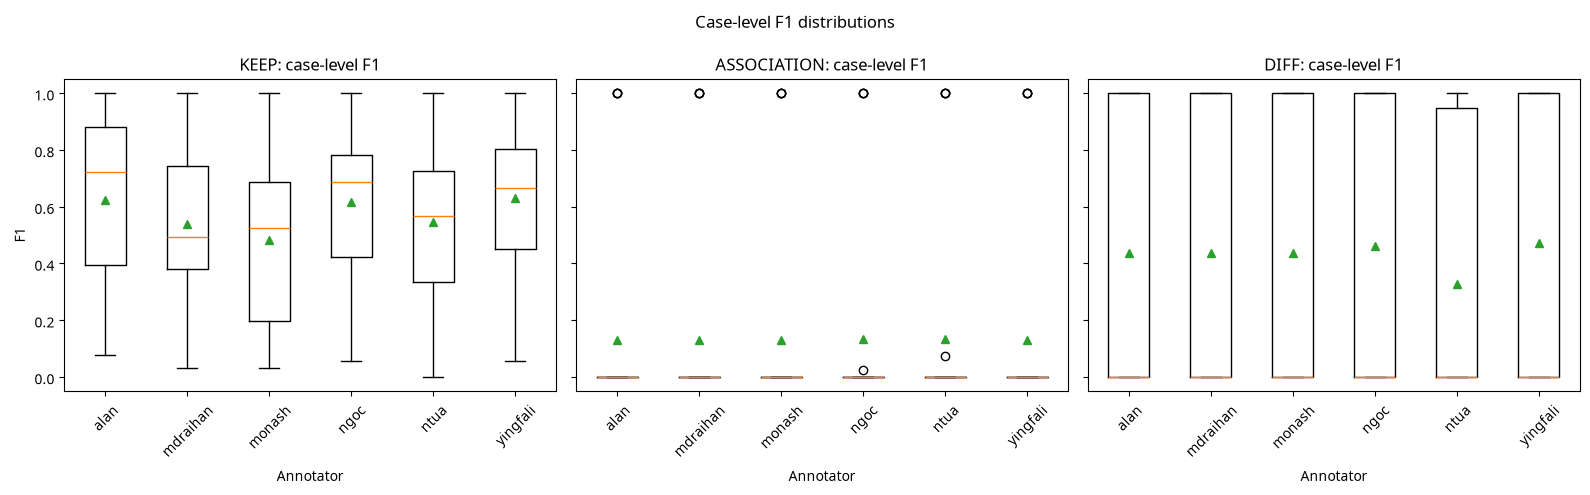

In [23]:
# Figure: distribution of case-level F1 by annotator and category.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, cat in zip(axes, CATEGORIES):
    subset = case_metrics_df[
        (case_metrics_df["Specialty"] == "Overall") &
        (case_metrics_df["Category"] == cat)
    ]
    data = [
        subset.loc[subset["Annotator"] == name, "F1"].values
        for name in names
    ]
    ax.boxplot(data, tick_labels=names, showmeans=True)
    ax.set_title(f"{cat}: case-level F1")
    ax.set_xlabel("Annotator")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("F1")
fig.suptitle("Case-level F1 distributions")
plt.tight_layout()
plt.show()

## 5. Statistical comparison of annotators

Because the same cases are evaluated for each annotator, case-level F1 scores can be compared using paired tests. Wilcoxon signed-rank tests are used when SciPy is available. These tests are supplementary and should not replace the descriptive results.

In [24]:
pairwise_tests = []

overall_case = case_metrics_df[
    (case_metrics_df["Specialty"] == "Overall")
]

for cat in CATEGORIES:
    wide = overall_case[overall_case["Category"] == cat].pivot(
        index="Case", columns="Annotator", values="F1"
    )

    for a, b in combinations(names, 2):
        pair = wide[[a, b]].dropna()
        if SCIPY_AVAILABLE and len(pair) >= 2:
            try:
                stat, p = wilcoxon(pair[a], pair[b], zero_method="wilcox", alternative="two-sided")
            except ValueError:
                stat, p = np.nan, np.nan
        else:
            stat, p = np.nan, np.nan

        pairwise_tests.append({
            "Category": cat,
            "Annotator_A": a,
            "Annotator_B": b,
            "N_cases": len(pair),
            "Wilcoxon_stat": stat,
            "p_value": p,
        })

pairwise_tests_df = pd.DataFrame(pairwise_tests)
display(pairwise_tests_df.round(4))

,Category,Annotator_A,Annotator_B,N_cases,Wilcoxon_stat,p_value
0,KEEP,alan,mdraihan,23,NaN,NaN
1,KEEP,alan,monash,23,NaN,NaN
2,KEEP,alan,ngoc,23,NaN,NaN
3,KEEP,alan,ntua,23,NaN,NaN
4,KEEP,alan,yingfali,23,NaN,NaN
5,KEEP,mdraihan,monash,23,NaN,NaN
6,KEEP,mdraihan,ngoc,23,NaN,NaN
7,KEEP,mdraihan,ntua,23,NaN,NaN
8,KEEP,mdraihan,yingfali,23,NaN,NaN
9,KEEP,monash,ngoc,23,NaN,NaN


## 6. Category prevalence and annotation-volume comparison

This section compares how many items the solution contains with how many items each annotator produces. Large differences in annotation volume can help explain low recall or low precision.

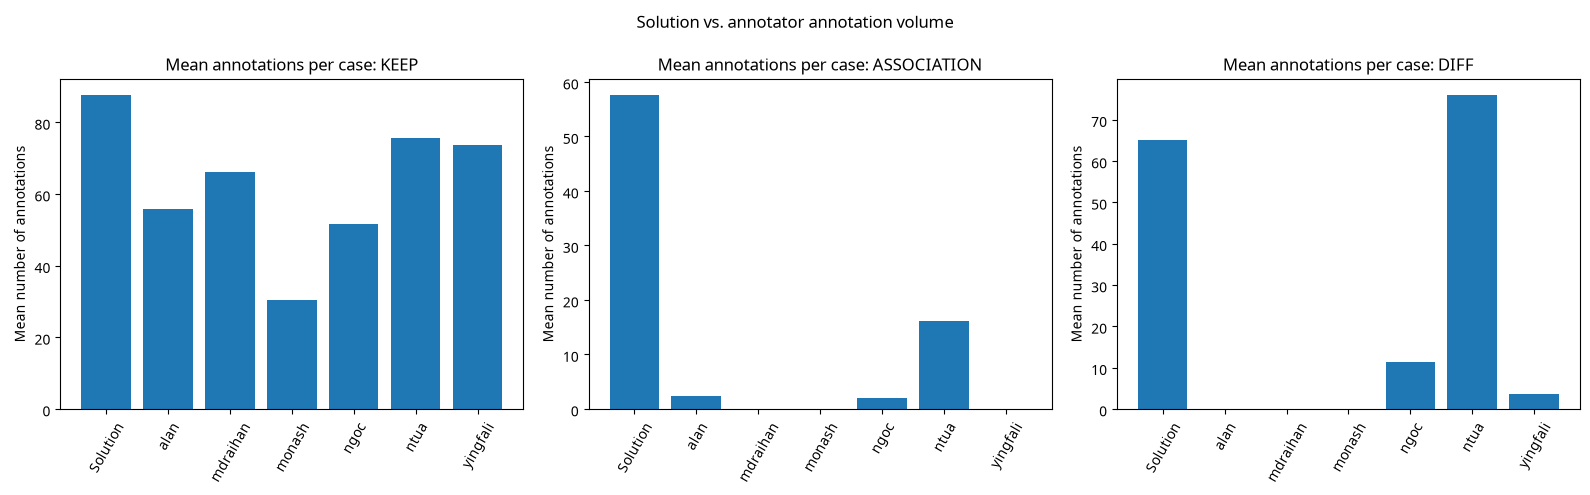

In [25]:
volume = annotation_counts.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cat in zip(axes, CATEGORIES):
    sub = volume[volume["Category"] == cat].copy()
    ax.bar(sub["Dataset"], sub["Mean"])
    ax.set_title(f"Mean annotations per case: {cat}")
    ax.set_ylabel("Mean number of annotations")
    ax.tick_params(axis="x", rotation=60)

fig.suptitle("Solution vs. annotator annotation volume")
plt.tight_layout()
plt.show()

In [26]:
# Annotation-volume ratio relative to the solution.
solution_means = (
    volume[volume["Dataset"] == "Solution"]
    .set_index("Category")["Mean"]
)

volume_ratio = volume.copy()
volume_ratio["Solution_mean"] = volume_ratio["Category"].map(solution_means)
volume_ratio["Volume_ratio_to_solution"] = (
    volume_ratio["Mean"] / volume_ratio["Solution_mean"]
)

display(
    volume_ratio[
        volume_ratio["Dataset"] != "Solution"
    ][["Dataset", "Category", "Mean", "Solution_mean", "Volume_ratio_to_solution"]]
    .round(3)
)

,Dataset,Category,Mean,Solution_mean,Volume_ratio_to_solution
3,alan,KEEP,55.826,87.739,0.636
4,alan,ASSOCIATION,2.391,57.696,0.041
5,alan,DIFF,0.000,65.000,0.000
6,mdraihan,KEEP,66.174,87.739,0.754
7,mdraihan,ASSOCIATION,0.000,57.696,0.000
8,mdraihan,DIFF,0.000,65.000,0.000
9,monash,KEEP,30.261,87.739,0.345
10,monash,ASSOCIATION,0.000,57.696,0.000
11,monash,DIFF,0.000,65.000,0.000
12,ngoc,KEEP,51.696,87.739,0.589


## 7. Annotation volume versus performance

The following scatter plot tests whether annotation volume is associated with F1. This is descriptive rather than causal.

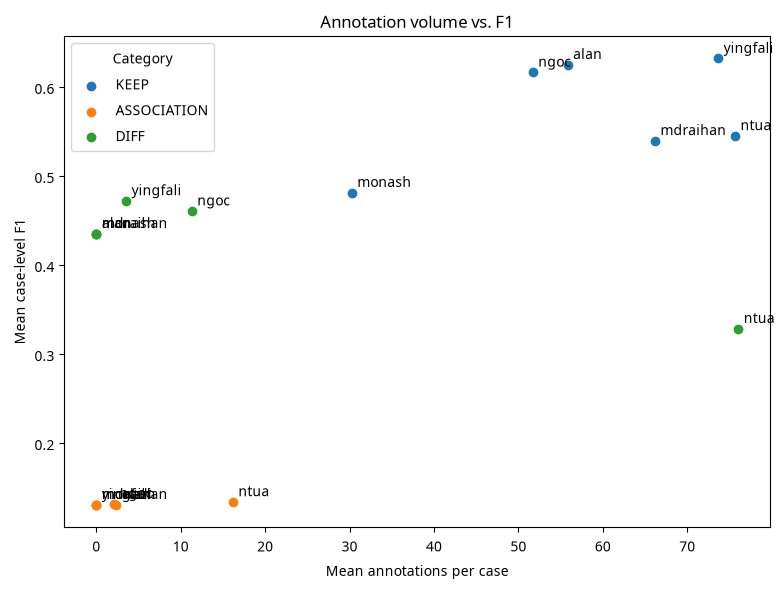

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

for cat in CATEGORIES:
    sub = error_summary[
        (error_summary["Specialty"] == "Overall") &
        (error_summary["Category"] == cat)
    ]
    volume_sub = volume[
        (volume["Dataset"].isin(names)) &
        (volume["Category"] == cat)
    ].set_index("Dataset")

    x = volume_sub.loc[sub["Annotator"], "Mean"].values
    y = sub["Macro_F1"].values
    ax.scatter(x, y, label=cat)

    for xi, yi, label in zip(x, y, sub["Annotator"]):
        ax.annotate(label, (xi, yi), xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Mean annotations per case")
ax.set_ylabel("Mean case-level F1")
ax.set_title("Annotation volume vs. F1")
ax.legend(title="Category")
plt.tight_layout()
plt.show()

## 8. Pairwise inter-annotator agreement for all categories

The original notebook calculated pairwise κ for KEEP only. The same diagnostic is extended to ASSOCIATION and DIFF.

In [28]:
iaa_all = {}
for cat in CATEGORIES:
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    for a in names:
        mat.loc[a, a] = 1.0
    for a, b in combinations(names, 2):
        k = corpus_kappa(annotators[a][cat], annotators[b][cat])
        mat.loc[a, b] = k
        mat.loc[b, a] = k
    iaa_all[cat] = mat

for cat, mat in iaa_all.items():
    print(f"Pairwise κ — {cat}")
    display(mat.round(3))

Pairwise κ — KEEP


,alan,mdraihan,monash,ngoc,ntua,yingfali
alan,1.000,0.556,0.508,0.858,0.733,0.688
mdraihan,0.556,1.000,0.439,0.573,0.713,0.708
monash,0.508,0.439,1.000,0.520,0.402,0.457
ngoc,0.858,0.573,0.520,1.000,0.697,0.754
ntua,0.733,0.713,0.402,0.697,1.000,0.838
yingfali,0.688,0.708,0.457,0.754,0.838,1.000


Pairwise κ — ASSOCIATION


,alan,mdraihan,monash,ngoc,ntua,yingfali
alan,1.000,0.0,0.0,-0.022,-0.010,0.0
mdraihan,0.000,1.0,1.0,0.000,0.000,1.0
monash,0.000,1.0,1.0,0.000,0.000,1.0
ngoc,-0.022,0.0,0.0,1.000,-0.009,0.0
ntua,-0.010,0.0,0.0,-0.009,1.000,0.0
yingfali,0.000,1.0,1.0,0.000,0.000,1.0


Pairwise κ — DIFF


,alan,mdraihan,monash,ngoc,ntua,yingfali
alan,1.0,1.0,1.0,0.000,0.000,0.000
mdraihan,1.0,1.0,1.0,0.000,0.000,0.000
monash,1.0,1.0,1.0,0.000,0.000,0.000
ngoc,0.0,0.0,0.0,1.000,0.119,-0.016
ntua,0.0,0.0,0.0,0.119,1.000,0.036
yingfali,0.0,0.0,0.0,-0.016,0.036,1.000


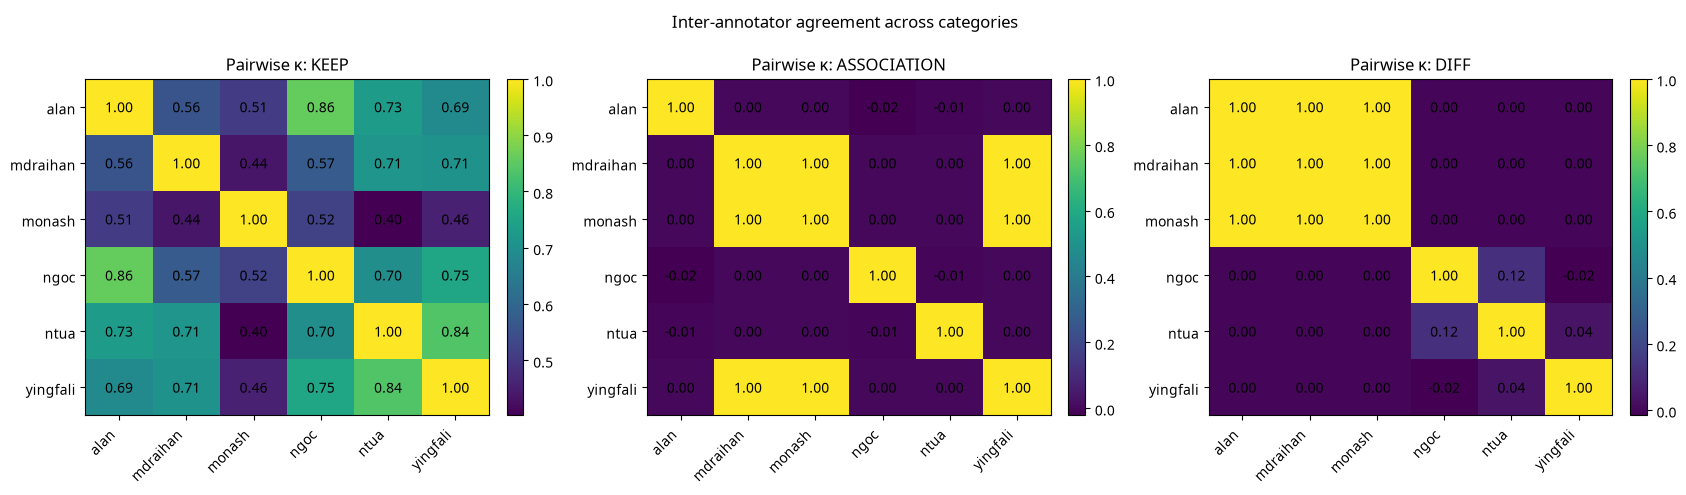

In [29]:
# Heatmaps for pairwise agreement.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, cat in zip(axes, CATEGORIES):
    mat = iaa_all[cat].astype(float)
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_xticks(range(len(names)), names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)), names)
    ax.set_title(f"Pairwise κ: {cat}")

    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{mat.iloc[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Inter-annotator agreement across categories")
plt.tight_layout()
plt.show()

## 9. Item-level annotator consensus

For each case and category, count how many annotators selected each item. This distinguishes items that are widely agreed upon from items that are controversial.

In [30]:
def consensus_by_item(annotator_dfs, solution_df, category):
    rows = []

    for case_idx in range(len(solution_df)):
        solution_items = parse_set(solution_df.iloc[case_idx][category])

        item_votes = {}
        for name, df in annotator_dfs.items():
            for item in parse_set(df.iloc[case_idx][category]):
                item_votes.setdefault(item, set()).add(name)

        all_items = set(item_votes) | solution_items

        for item in all_items:
            voters = item_votes.get(item, set())
            rows.append({
                "Case": case_idx,
                "Category": category,
                "Item": item,
                "Votes": len(voters),
                "In_solution": item in solution_items,
                "Annotators": ", ".join(sorted(voters)),
            })

    return pd.DataFrame(rows)

consensus_frames = [
    consensus_by_item(annotators, solution, cat)
    for cat in CATEGORIES
]
consensus_df = pd.concat(consensus_frames, ignore_index=True)

consensus_summary = (
    consensus_df
    .groupby(["Category", "Votes", "In_solution"])
    .size()
    .reset_index(name="Items")
)

display(consensus_summary)

,Category,Votes,In_solution,Items
0,ASSOCIATION,0,True,1318
1,ASSOCIATION,1,False,466
2,ASSOCIATION,1,True,9
3,DIFF,0,True,1219
4,DIFF,1,False,1647
5,DIFF,1,True,109
6,DIFF,2,True,167
7,KEEP,0,True,560
8,KEEP,1,False,462
9,KEEP,1,True,190


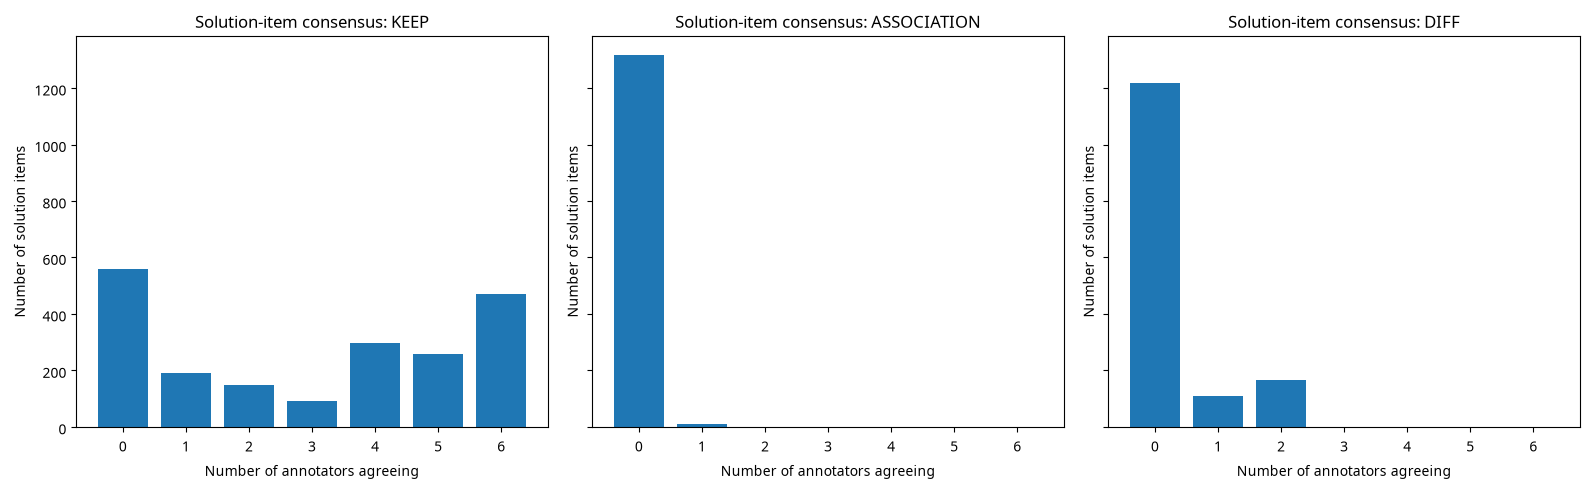

In [31]:
# Solution-item consensus distribution.
solution_consensus = consensus_df[consensus_df["In_solution"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, cat in zip(axes, CATEGORIES):
    counts = (
        solution_consensus[solution_consensus["Category"] == cat]["Votes"]
        .value_counts()
        .reindex(range(0, len(names) + 1), fill_value=0)
        .sort_index()
    )
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"Solution-item consensus: {cat}")
    ax.set_xlabel("Number of annotators agreeing")
    ax.set_ylabel("Number of solution items")

plt.tight_layout()
plt.show()

### Corrected under-retrieval statistic (fixes the "roughly a fifth" claim)

The under-retrieval argument should cite the share of **solution KEEP items that no annotator ever selected** (zero-vote items), computed directly from `consensus_df` and cross-checked against the total solution KEEP count reconstructed from `error_summary` (TP + FN is the same for every annotator, since they're all scored against the same solution).

In [32]:
keep_zero_votes = int(
    consensus_df.query("Category == 'KEEP' and In_solution and Votes == 0").shape[0]
)
_keep_row = error_summary.query("Specialty == 'Overall' and Category == 'KEEP'").iloc[0]
keep_total_solution_items = int(_keep_row["TP"] + _keep_row["FN"])
keep_zero_share = keep_zero_votes / keep_total_solution_items

print(f"{keep_zero_votes} of {keep_total_solution_items} solution KEEP items "
      f"({keep_zero_share:.1%}) were never selected by any annotator.")


560 of 2018 solution KEEP items (27.8%) were never selected by any annotator.


## 10. Ensemble-size analysis

The original notebook already searches union and majority-vote ensembles. This section summarizes the best ensemble at each size and measures the marginal gain/loss from adding annotators.

In [33]:
best_by_size = (
    ens_df.assign(
        ensemble_size=ens_df["dataframes"].str.count(",") + 1
    )
    .sort_values(["ensemble_size", "avg_f1"], ascending=[True, False])
    .groupby(["ensemble_size", "strategy"], as_index=False)
    .first()
    .sort_values(["ensemble_size", "strategy"])
)

display(best_by_size.round(3))

,ensemble_size,strategy,dataframes,avg_f1,f1_keep,f1_association,f1_diff
0,1,majority,yingfali,0.411,0.632,0.130,0.472
1,1,union,yingfali,0.411,0.632,0.130,0.472
2,2,majority,"ngoc, yingfali",0.385,0.589,0.130,0.435
3,2,union,"alan, yingfali",0.427,0.678,0.130,0.472
4,3,majority,"alan, ngoc, ntua",0.404,0.611,0.130,0.471
5,3,union,"alan, ngoc, yingfali",0.438,0.685,0.132,0.497
6,4,majority,"alan, mdraihan, ngoc, yingfali",0.383,0.583,0.130,0.435
7,4,union,"alan, monash, ngoc, yingfali",0.430,0.662,0.132,0.497
8,5,majority,"alan, mdraihan, ngoc, ntua, yingfali",0.393,0.615,0.130,0.435
9,5,union,"alan, mdraihan, monash, ngoc, yingfali",0.419,0.628,0.132,0.497


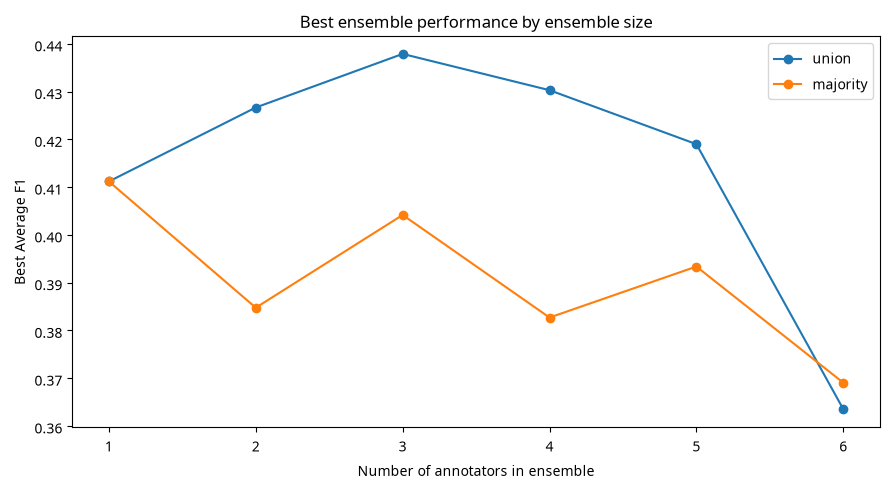

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

for strategy in ["union", "majority"]:
    sub = best_by_size[best_by_size["strategy"] == strategy]
    ax.plot(
        sub["ensemble_size"],
        sub["avg_f1"],
        marker="o",
        label=strategy
    )

ax.set_xlabel("Number of annotators in ensemble")
ax.set_ylabel("Best Average F1")
ax.set_title("Best ensemble performance by ensemble size")
ax.legend()
ax.set_xticks(sorted(best_by_size["ensemble_size"].unique()))
plt.tight_layout()
plt.show()

In [35]:
best_by_size = best_by_size.sort_values(["strategy", "ensemble_size"]).copy()
best_by_size["Marginal_gain"] = (
    best_by_size.groupby("strategy")["avg_f1"].diff()
)

display(
    best_by_size[
        ["ensemble_size", "strategy", "dataframes", "avg_f1", "Marginal_gain"]
    ].round(3)
)

,ensemble_size,strategy,dataframes,avg_f1,Marginal_gain
0,1,majority,yingfali,0.411,NaN
2,2,majority,"ngoc, yingfali",0.385,-0.026
4,3,majority,"alan, ngoc, ntua",0.404,0.019
6,4,majority,"alan, mdraihan, ngoc, yingfali",0.383,-0.021
8,5,majority,"alan, mdraihan, ngoc, ntua, yingfali",0.393,0.011
10,6,majority,"alan, mdraihan, monash, ngoc, ntua, yingfali",0.369,-0.024
1,1,union,yingfali,0.411,NaN
3,2,union,"alan, yingfali",0.427,0.015
5,3,union,"alan, ngoc, yingfali",0.438,0.011
7,4,union,"alan, monash, ngoc, yingfali",0.430,-0.008


## 11. Sensitivity analysis for the empty-vs-empty F1 convention

The original `f1_score()` assigns F1 = 1 when both prediction and solution are empty. This is retained for the primary analysis. The following sensitivity analysis recomputes mean F1 under alternative conventions to show whether annotator rankings are robust.

In [36]:
def f1_with_convention(true, pred, empty_both="one"):
    """Compatibility wrapper for the section 11 sensitivity experiment."""
    return f1_average(true, pred, empty_both=empty_both)

sensitivity_rows = []

for annotator, df in annotators.items():
    for convention in ["one", "zero", "exclude"]:
        category_scores = []

        for cat in CATEGORIES:
            vals = [
                f1_with_convention(t, p, empty_both=convention)
                for t, p in zip(solution[cat], df[cat])
            ]
            vals = np.asarray(vals, dtype=float)
            category_scores.append(np.nanmean(vals))

        sensitivity_rows.append({
            "Annotator": annotator,
            "Convention": convention,
            "KEEP_F1": category_scores[0],
            "ASSOCIATION_F1": category_scores[1],
            "DIFF_F1": category_scores[2],
            "Average_F1": np.nanmean(category_scores),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

,Annotator,Convention,KEEP_F1,ASSOCIATION_F1,DIFF_F1,Average_F1
0,alan,one,0.625,0.130,0.435,0.397
1,alan,zero,0.625,0.000,0.000,0.208
2,alan,exclude,0.625,0.000,0.000,0.208
3,mdraihan,one,0.539,0.130,0.435,0.368
4,mdraihan,zero,0.539,0.000,0.000,0.180
5,mdraihan,exclude,0.539,0.000,0.000,0.180
6,monash,one,0.481,0.130,0.435,0.349
7,monash,zero,0.481,0.000,0.000,0.160
8,monash,exclude,0.481,0.000,0.000,0.160
9,ngoc,one,0.616,0.132,0.460,0.403


### Corrected ranking-stability claim (fixes "ntua/monash remain lowest under every convention")

Rather than eyeballing raw F1 differences across conventions, rank annotators (1 = best) within each convention. This shows which parts of the ranking are actually stable.

In [37]:
rank_by_convention = (
    sensitivity_df
    .pivot(index="Annotator", columns="Convention", values="Average_F1")
    [["one", "zero", "exclude"]]
)
ranks = rank_by_convention.rank(ascending=False).astype(int)

display(rank_by_convention.round(3))
display(ranks)

stable_top = ranks.index[(ranks <= 2).all(axis=1)].tolist()
unstable = ranks.index[~ranks.index.isin(stable_top)].tolist()
print(f"Annotators ranked in the top 2 under every convention: {stable_top}")
print(f"Annotators whose rank changes across conventions (positions 3-6 reorder): {unstable}")


Convention,one,zero,exclude
Annotator,,,
alan,0.397,0.208,0.208
mdraihan,0.368,0.180,0.180
monash,0.349,0.160,0.160
ngoc,0.403,0.214,0.221
ntua,0.335,0.205,0.213
yingfali,0.411,0.223,0.232


Convention,one,zero,exclude
Annotator,,,
alan,3,3,4
mdraihan,4,5,5
monash,5,6,6
ngoc,2,2,2
ntua,6,4,3
yingfali,1,1,1


Annotators ranked in the top 2 under every convention: ['ngoc', 'yingfali']
Annotators whose rank changes across conventions (positions 3-6 reorder): ['alan', 'mdraihan', 'monash', 'ntua']


## 12. Requested Private-case Results

Equal weighting of the three categories is useful for interpretability, but it can hide the influence of category prevalence. This section reports both macro-F1 and pooled micro-F1.

In [38]:
# Exact reference-score calculation for the requested Private cases.
# This is intentionally the same score() logic as f1-score-average.ipynb.
def reference_parse_codes(x):
    if pd.isna(x) or x == "":
        return set()
    return {code.strip() for code in str(x).split("; ") if code.strip()}


def reference_f1_sets(true_set, pred_set):
    """Use the canonical section 12 set-level formula."""
    tp = len(true_set & pred_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)
    if tp == 0 and fp == 0 and fn == 0:
        return 1.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * precision * recall / (precision + recall) if precision + recall else 0.0


def reference_score(solution_df, submission_df, row_id_column_name):
    submission_df = submission_df.sort_values(row_id_column_name).reset_index(drop=True)
    solution_df = solution_df.sort_values(row_id_column_name).reset_index(drop=True)
    for col in CATEGORIES:
        submission_df[col] = (
            submission_df[col].replace("Not Applicable", "").fillna("").astype(str)
        )
        solution_df[col] = (
            solution_df[col]
            .replace(["nan", "None", "NaN"], "")
            .replace("Not Applicable", "")
            .fillna("")
            .astype(str)
        )

    row_scores = []
    for i in range(len(solution_df)):
        category_scores = []
        for col in CATEGORIES:
            true_set = reference_parse_codes(solution_df.iloc[i][col])
            pred_set = reference_parse_codes(submission_df.iloc[i][col])
            category_scores.append(reference_f1_sets(true_set, pred_set))
        row_scores.append(sum(category_scores) / 3)
    return float(sum(row_scores) / len(row_scores))

private_idx = solution.index[solution["Usage"].eq("Private")].tolist()
private_solution = solution.iloc[private_idx][["Condition", *CATEGORIES]].reset_index(drop=True)

private_display_names = {
    "yingfali": "Yingfali",
    "ngoc": "Ngọc Hưng Nguyễn",
    "alan": "Alan T. Andrea",
    "mdraihan": "Md Raihan",
    "monash": "Monash AIM",
    "ntua": "NTUA",
}

private_results = []
for name, df in annotators.items():
    private_submission = df.iloc[private_idx][["Condition", *CATEGORIES]].reset_index(drop=True)
    private_results.append({
        "Annotator": private_display_names[name],
        "Average_F1": reference_score(private_solution.copy(), private_submission.copy(), "Condition"),
    })

private_results_df = (
    pd.DataFrame(private_results)
    .sort_values("Average_F1", ascending=False)
    .reset_index(drop=True)
)
private_results_df["F1"] = np.floor(private_results_df["Average_F1"] * 100000) / 100000
display(private_results_df[["Annotator", "F1"]])
private_results_df.to_csv("evaluation_results.csv", index=False)


,Annotator,F1
0,Yingfali,0.37995
1,Ngọc Hưng Nguyễn,0.37765
2,Alan T. Andrea,0.37707
3,Md Raihan,0.37042
4,Monash AIM,0.34882
5,NTUA,0.30942


## 13. Consolidated Results tables

The following tables are intended to be exported directly for the Results chapter.

In [39]:
# Table A — requested Private-case annotator F1 results.
# This replaces the former all-row Overall table.
display(private_results_df.round(5))

# Table B — error decomposition for diagnostics (Overall specialty).
# Micro_* columns are pooled-TP/FP/FN based (internally consistent with each
# other); Macro_* columns are the mean of per-case scores and match the
# convention used for Table A. See the Table 3 fix note in Section 3.
display(
    error_summary[error_summary["Specialty"] == "Overall"]
    [["Annotator", "Category", "TP", "FP", "FN",
      "Micro_Precision", "Micro_Recall", "Micro_F1",
      "Macro_Precision", "Macro_Recall", "Macro_F1"]]
    .sort_values(["Category", "Macro_F1"], ascending=[True, False])
    .round(3)
)

# Table C — top ensembles.
display(ens_df.head(15).round(3))


,Annotator,Average_F1,F1
0,Yingfali,0.37996,0.37995
1,Ngọc Hưng Nguyễn,0.37765,0.37765
2,Alan T. Andrea,0.37708,0.37707
3,Md Raihan,0.37042,0.37042
4,Monash AIM,0.34882,0.34882
5,NTUA,0.30942,0.30942


,Annotator,Category,TP,FP,FN,Micro_Precision,Micro_Recall,Micro_F1,Macro_Precision,Macro_Recall,Macro_F1
66,ntua,ASSOCIATION,8,364,1319,0.022,0.006,0.009,0.003,0.003,0.134
63,ngoc,ASSOCIATION,1,47,1326,0.021,0.001,0.001,0.001,0.001,0.132
54,alan,ASSOCIATION,0,55,1327,0.000,0.000,0.000,0.000,0.000,0.130
57,mdraihan,ASSOCIATION,0,0,1327,0.000,0.000,0.000,0.000,0.000,0.130
60,monash,ASSOCIATION,0,0,1327,0.000,0.000,0.000,0.000,0.000,0.130
69,yingfali,ASSOCIATION,0,0,1327,0.000,0.000,0.000,0.000,0.000,0.130
70,yingfali,DIFF,81,0,1414,1.000,0.054,0.103,0.043,0.032,0.472
64,ngoc,DIFF,130,130,1365,0.500,0.087,0.148,0.022,0.031,0.460
55,alan,DIFF,0,0,1495,0.000,0.000,0.000,0.000,0.000,0.435
58,mdraihan,DIFF,0,0,1495,0.000,0.000,0.000,0.000,0.000,0.435


,dataframes,strategy,avg_f1,f1_keep,f1_association,f1_diff
0,"alan, ngoc, yingfali",union,0.438,0.685,0.132,0.497
1,"alan, monash, ngoc, yingfali",union,0.430,0.662,0.132,0.497
2,"mdraihan, ngoc, yingfali",union,0.429,0.657,0.132,0.497
3,"alan, yingfali",union,0.427,0.678,0.130,0.472
4,"alan, mdraihan, ngoc, yingfali",union,0.426,0.651,0.132,0.497
5,"ngoc, yingfali",union,0.426,0.650,0.132,0.497
6,"alan, monash, yingfali",union,0.421,0.662,0.130,0.472
7,"alan, ngoc",union,0.421,0.673,0.132,0.460
8,"monash, ngoc, yingfali",union,0.421,0.635,0.132,0.497
9,"mdraihan, yingfali",union,0.420,0.659,0.130,0.472


### Table D — annotator-level Micro-F1 vs. Macro-F1 (fixes "micro is lower than macro for every annotator except ngoc and yingfali")

Table B pools TP/FP/FN *within* each category. This table pools TP/FP/FN *across all three categories* (KEEP + ASSOCIATION + DIFF) and all cases into a single precision/recall/F1 per annotator, and compares it to the macro-F1 already reported for Table A/Section 11 (the `"one"` empty-vs-empty convention, averaged over the three categories). Micro-F1 down-weights rare categories relative to KEEP (which dominates the pooled counts), which is why it sits below macro-F1 for every annotator here, including ngoc and yingfali.

In [40]:
_pooled_all = (
    error_summary[error_summary["Specialty"] == "Overall"]
    .groupby("Annotator")[["TP", "FP", "FN"]]
    .sum()
)
_pooled_all["Micro_Precision"] = _pooled_all["TP"] / (_pooled_all["TP"] + _pooled_all["FP"])
_pooled_all["Micro_Recall"] = _pooled_all["TP"] / (_pooled_all["TP"] + _pooled_all["FN"])
_pooled_all["Micro_F1"] = (
    2 * _pooled_all["Micro_Precision"] * _pooled_all["Micro_Recall"]
    / (_pooled_all["Micro_Precision"] + _pooled_all["Micro_Recall"])
)

_macro_all = (
    sensitivity_df[sensitivity_df["Convention"] == "one"]
    .set_index("Annotator")["Average_F1"]
    .rename("Macro_F1")
)

micro_macro_overall = _pooled_all.join(_macro_all).reset_index()
micro_macro_overall["Annotator"] = micro_macro_overall["Annotator"].map(private_display_names)
micro_macro_overall = micro_macro_overall[
    ["Annotator", "TP", "FP", "FN", "Micro_Precision", "Micro_Recall", "Micro_F1", "Macro_F1"]
].sort_values("Macro_F1", ascending=False).reset_index(drop=True)
micro_macro_overall["Rank_micro"] = micro_macro_overall["Micro_F1"].rank(ascending=False).astype(int)
micro_macro_overall["Rank_macro"] = micro_macro_overall["Macro_F1"].rank(ascending=False).astype(int)

display(micro_macro_overall.round(4))

_lower = (micro_macro_overall["Micro_F1"] < micro_macro_overall["Macro_F1"]).all()
print(f"Micro-F1 is lower than macro-F1 for all {len(micro_macro_overall)} annotators: {_lower}")
_moved = micro_macro_overall.loc[
    micro_macro_overall["Annotator"] == "NTUA", ["Rank_micro", "Rank_macro"]
]
print(f"NTUA rank (macro -> micro): {_moved['Rank_macro'].item()} -> {_moved['Rank_micro'].item()}")


,Annotator,TP,FP,FN,Micro_Precision,Micro_Recall,Micro_F1,Macro_F1,Rank_micro,Rank_macro
0,Yingfali,1320,455,3520,0.7437,0.2727,0.3991,0.4112,1,1
1,Ngọc Hưng Nguyễn,1255,242,3585,0.8383,0.2593,0.3961,0.4026,2,2
2,Alan T. Andrea,1137,202,3703,0.8491,0.2349,0.3680,0.3966,3,3
3,Md Raihan,855,667,3985,0.5618,0.1767,0.2688,0.3681,5,4
4,Monash AIM,627,69,4213,0.9009,0.1295,0.2265,0.3487,6,5
5,NTUA,1333,2528,3507,0.3452,0.2754,0.3064,0.3355,4,6


Micro-F1 is lower than macro-F1 for all 6 annotators: True
NTUA rank (macro -> micro): 6 -> 4


## 14. Export enhanced analysis

All major outputs are written as CSV files so that the Results chapter can use exact values without manually copying notebook output.

In [41]:
# Exported after private_results_df is created below.
iaa_kappa.to_csv("inter_annotator_agreement_KEEP.csv")
for cat, mat in iaa_all.items():
    mat.to_csv(f"inter_annotator_agreement_{cat}.csv")

ens_df.to_csv("ensemble_search_results.csv", index=False)
annotation_counts.to_csv("annotation_counts_robust.csv", index=False)
error_summary.to_csv("error_decomposition.csv", index=False)
case_ci_df.to_csv("case_level_f1_confidence_intervals.csv", index=False)
pairwise_tests_df.to_csv("pairwise_annotator_tests.csv", index=False)
consensus_df.to_csv("item_level_consensus.csv", index=False)
best_by_size.to_csv("ensemble_size_analysis.csv", index=False)
sensitivity_df.to_csv("f1_sensitivity_analysis.csv", index=False)
private_results_df.to_csv("private_case_f1.csv", index=False)
micro_macro_overall.to_csv("annotator_micro_vs_macro_f1.csv", index=False)
validation_df.to_csv("data_validation_report.csv", index=False)

print("Enhanced analysis outputs saved.")

Enhanced analysis outputs saved.


## Corrected Results-chapter text

Ready-to-paste replacements for the seven reviewer comments. Each one is backed by a table/cell above in this
notebook rather than typed by hand, so re-running the notebook re-verifies the numbers.

**1. Table 3 caption.** Replaced by the Table 3 fix note in Section 3: report Micro-\* (pooled TP/FP/FN, mutually
consistent) and Macro-\* (mean per-case, matches Table A) as separate columns, never mixed in one Precision/Recall/F1
triple.

**2 & 5. "Only ngoc, ntua, and yingfali produced ASSOCIATION/DIFF" / "five of six annotators never used
ASSOCIATION or DIFF."** Corrected: *two* annotators — mdraihan and monash — never produced any ASSOCIATION or DIFF
items. A third, alan, produced 55 ASSOCIATION items, all of them false positives (0 true positives) — abstaining and
producing 55 wrong items are different findings, and the latter is arguably the more interesting one for the
Results chapter.

**3. "Five of six annotators recorded 0.00 DIFF/four of six recorded 0.00 ASSOCIATION."** Corrected: Table 4 shows
*three* of six for each — DIFF zeros are alan, mdraihan, monash; ASSOCIATION zeros are mdraihan, monash, yingfali.
Only mdraihan and monash are zero on both.

**4. "Roughly a fifth of all solution KEEP items."** Corrected: 560 of 2,018 solution KEEP items (27.8%) were never
selected by any annotator — "more than a quarter," not "roughly a fifth."

**6. "ntua/monash remain the lowest under every convention."** Corrected: only under the "one" convention is ntua
lowest. Under "excluded" ntua is third (0.213), ahead of alan (0.208, the announced third-place winner); under
"zero" ntua is fourth. Only yingfali and ngoc hold stable ranks (1st and 2nd) across all three conventions —
suggested wording: *"the top two are stable across all conventions; positions three to six reorder."*

**7. "Micro-F1 is lower than macro-F1 for every annotator except ngoc and yingfali."** Corrected: Table D shows
micro-F1 below macro-F1 for **all six** annotators, including ngoc (0.403 → 0.396) and yingfali (0.411 → 0.399).
Under micro-F1, ntua also moves above *both* mdraihan and monash (macro rank 6th → micro rank 4th), not just
mdraihan.


## Interpretation checklist

Before finalizing the Results section, verify:

- [ ] specialty row indices have been validated against the source data;
- [ ] annotator rows are aligned to the solution using a stable case ID, if available;
- [ ] annotation counts use `parse_set()` rather than semicolon counting;
- [ ] precision and recall are reported alongside F1;
- [ ] case-level confidence intervals are reported for key comparisons;
- [ ] empty-vs-empty F1 sensitivity does not materially change the conclusions;
- [ ] macro and micro F1 are both considered;
- [ ] pairwise agreement is clearly labelled as inter-annotator agreement, not correctness;
- [ ] ensemble performance is compared by ensemble size and strategy;
- [ ] low-consensus solution items are discussed as potential sources of ambiguity.

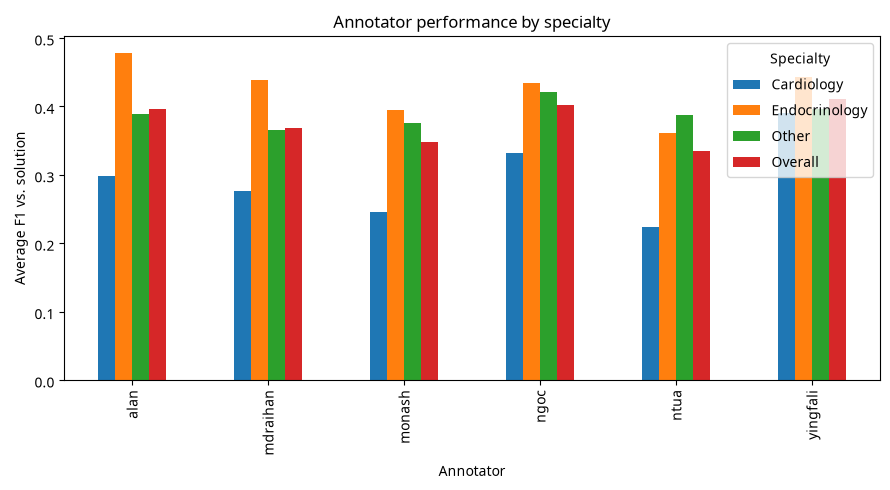

In [42]:
# Reproduced Figure 2: annotator performance by specialty
if 'specialty_results_df' in globals():
    _plot_df = specialty_results_df.copy()
elif 'specialty_df' in globals():
    _plot_df = specialty_df.copy()
else:
    _plot_df = results_df.copy()
_plot_df.pivot(index='Annotator', columns='Specialty', values='Average_F1').plot(kind='bar', figsize=(9,5), title='Annotator performance by specialty')
plt.ylabel('Average F1 vs. solution'); plt.xlabel('Annotator'); plt.tight_layout(); plt.show()
